In [ ]:
# ---------------- Install all required packages ----------------
%pip install --upgrade pip

# Install PyTorch 2.8.0 CPU and compatible torchvision
%pip install torch==2.8.0 torchvision==0.23.0 --index-url https://download.pytorch.org/whl/cpu

# Install scikit-learn
%pip install scikit-learn

# Optional: Install pillow and ipywidgets if missing
%pip install pillow ipywidgets




In [ ]:
pip install matplotlib


In [ ]:
pip install pandas

In [14]:

import os
import time
import glob
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch.nn.functional as F

# optional: for notebook file upload UI
try:
    from ipywidgets import FileUpload, VBox, Button, Output
    from IPython.display import display
    _have_ipy = True
except Exception:
    _have_ipy = False


In [15]:


# ------------------- User config -------------------
DATA_DIR = "E:/detect  deepfake/deepfake-detector/dataset/train"  # change if needed
WORK_DIR = "E:/detect  deepfake/deepfake-detector/dataset"  # where checkpoints will be saved (writable)
os.makedirs(WORK_DIR, exist_ok=True)

import os

if os.path.exists(WORK_DIR):
    print(f"Directory exists: {DATA_DIR}")
else:
    print(f"Directory does NOT exist: {DATA_DIR}")


import os

for folder in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, folder)
    if os.path.isdir(path):
        print(f"Class folder: {folder}, #images: {len(os.listdir(path))}")

Directory exists: E:/detect  deepfake/deepfake-detector/dataset/train
Class folder: fake, #images: 5004
Class folder: real, #images: 5004


In [16]:
MAX_PER_CLASS = None  # set to None to load everything; or an int like 400 for quick tests
IMG_SIZE = 224
BATCH = 32               # tune according to GPU memory (16/32)
EPOCHS = 20               # total epochs you plan to run; you can stop earlier and resume
LR = 0.01
STEP = 10
GAMMA = 0.1
NUM_WORKERS = 4          # dataloader workers
PIN_MEMORY = True if torch.cuda.is_available() else False
SAVE_EVERY_N_EPOCHS = 1  # save checkpoint every epoch
# ---------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ------------------- Helpers: dataset dataframe -------------------
def create_df(path, max_per_class=None):
    dd = {"images": [], "labels": []}
    for label in sorted(os.listdir(path)):
        img_dir = os.path.join(path, label)
        if not os.path.isdir(img_dir):
            continue
        index = 0
        for img_name in sorted(os.listdir(img_dir)):
            full = os.path.join(img_dir, img_name)
            if not os.path.isfile(full):
                continue
            dd["images"].append(full)
            dd["labels"].append(label)
            index += 1
            if max_per_class is not None and index >= max_per_class:
                break
    # RETURN AFTER PROCESSING ALL CLASSES
    return pd.DataFrame(dd)

    
print("Building dataframe (this may take a bit)...")
df = create_df(DATA_DIR, max_per_class=MAX_PER_CLASS)
print("Total images listed:", len(df))

# label encoding
index_label = {i: label for i, label in enumerate(sorted(df["labels"].unique()))}
label_index = {label: i for i, label in index_label.items()}
df["labels"] = df["labels"].map(label_index)
OUT_SIZE = len(index_label)
print("Classes:", index_label)


Device: cpu
Building dataframe (this may take a bit)...
Total images listed: 10008
Classes: {0: 'fake', 1: 'real'}


In [17]:
# ------------------- Dataset & transforms -------------------
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class Pipeline(Dataset):
    def __init__(self, data, transform):
        super().__init__()
        self.data = data  # numpy array of [path, label]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx, 0]
        label = int(self.data[idx, 1])
        img = Image.open(img_path).convert("RGB")
        img = np.array(img)
        img = self.transform(img)
        return img, label

NUM_WORKERS = 0  # safe for Windows

In [18]:
# ------------------- Train/val/test split -------------------
train_arr, val_arr = train_test_split(df.values, random_state=42, test_size=0.2, shuffle=True)
val_arr, test_arr = train_test_split(val_arr, random_state=42, test_size=0.5, shuffle=True)

train_ds = Pipeline(train_arr, transform)
val_ds = Pipeline(val_arr, transform)
test_ds = Pipeline(test_arr, transform)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)


# ------------------- Model setup -------------------
base = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
num_ftrs = base.fc.in_features
base.fc = nn.Linear(num_ftrs, OUT_SIZE)

class WrapModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)  # raw logits

model = WrapModel(base).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=GAMMA)

# mixed precision scaler (optional)
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

In [19]:

# ------------------- Checkpoint utilities -------------------
def latest_checkpoint(dirpath):
    # returns latest epoch checkpoint by name pattern "checkpoint_epoch_*.pth" or None
    pat = os.path.join(dirpath, "checkpoint_epoch_*.pth")
    files = glob.glob(pat)
    if not files:
        latest = os.path.join(dirpath, "checkpoint_latest.pth")
        if os.path.exists(latest):
            return latest
        return None
    files_sorted = sorted(files, key=os.path.getmtime)
    return files_sorted[-1]

def save_checkpoint(state, dirpath, epoch):
    ts = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
    fname_epoch = os.path.join(dirpath, f"checkpoint_epoch_{epoch}_{ts}.pth")
    fname_latest = os.path.join(dirpath, "checkpoint_latest.pth")
    torch.save(state, fname_epoch)
    torch.save(state, fname_latest)
    print(f"Saved checkpoint: {fname_epoch} and checkpoint_latest.pth")

# resume if checkpoint exists
checkpoint_path = latest_checkpoint(WORK_DIR)
start_epoch = 0
best_val_acc = 0.0
if checkpoint_path:
    print("Found checkpoint:", checkpoint_path)
    ck = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ck["model_state"])
    optimizer.load_state_dict(ck["optimizer_state"])
    scheduler.load_state_dict(ck["scheduler_state"])
    start_epoch = ck.get("epoch", 0) + 1
    best_val_acc = ck.get("best_val_acc", 0.0)
    print(f"Resumed from epoch {start_epoch}, best_val_acc {best_val_acc:.4f}")
else:
    print("No checkpoint found. Training from scratch.")

No checkpoint found. Training from scratch.


In [ ]:
# ------------------- Training loop -------------------
def evaluate(dl, model, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for images, labs in dl:
            images = images.to(device)
            outputs = model(images)
            _, p = torch.max(outputs, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(labs.numpy())
    acc = accuracy_score(labels, preds) if len(labels) > 0 else 0.0
    return acc

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    t0 = time.time()
    for images, labels in train_dl:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        _, p = torch.max(outputs.detach(), 1)
        all_preds.extend(p.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(all_labels, all_preds) if len(all_labels) > 0 else 0.0
    avg_loss = running_loss / (len(train_dl) if len(train_dl) else 1)
    t_elapsed = time.time() - t0
    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {avg_loss:.4f} - train_acc: {train_acc:.4f} - time: {t_elapsed:.1f}s")

    # validate
    val_acc = evaluate(val_dl, model, device)
    print(f" Validation Acc: {val_acc:.4f}")

    # scheduler step
    scheduler.step()

    # Save checkpoint info
    state = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_acc": best_val_acc,
        "time": datetime.utcnow().isoformat()
    }
    if (epoch + 1) % SAVE_EVERY_N_EPOCHS == 0:
        save_checkpoint(state, WORK_DIR, epoch)

    # Save best model separately
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_path = os.path.join(WORK_DIR, "best_model.pth")
        torch.save(model.state_dict(), best_path)
        print(f" New best val_acc {best_val_acc:.4f} -> saved best_model.pth")

print("Training finished.")


# ------------------- Test evaluation (quick) -------------------
test_acc = evaluate(test_dl, model, device)
print("Test accuracy (on held-out split):", test_acc)





In [24]:
# ------------------- Load best model -------------------
best_model_path = os.path.join(WORK_DIR, "best_model.pth")
model = WrapModel(resnet50(weights=ResNet50_Weights.IMAGENET1K_V2))
num_ftrs = model.model.fc.in_features
model.model.fc = nn.Linear(num_ftrs, OUT_SIZE)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)
model.eval()
print("Best model loaded for inference.")


Best model loaded for inference.


In [37]:
!pip install opencv-python


  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl (39.0 MB)


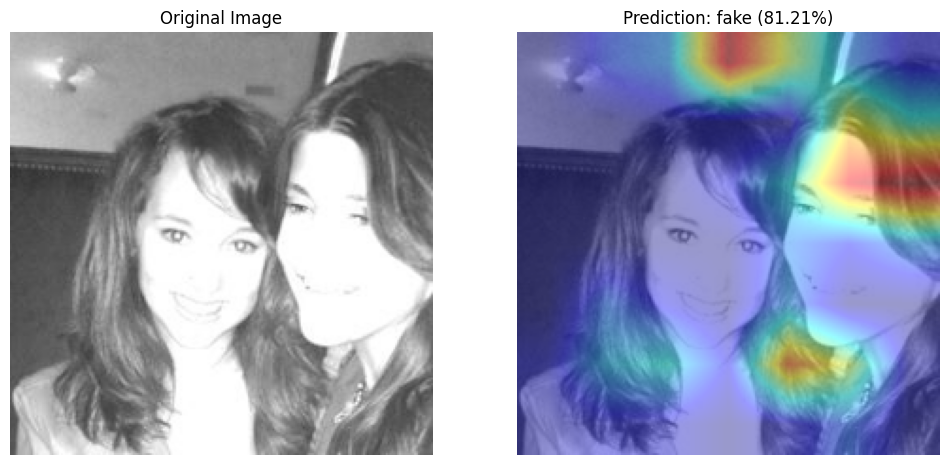

In [44]:
import torch
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Define constants
IMG_SIZE = 224  # change if your model expects different size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- Preprocess Function --------------------
def preprocess_image(img_path):
    img = Image.open(img_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return transform(img).unsqueeze(0)  # add batch dimension

# -------------------- Prediction + GradCAM --------------------
def predict_and_gradcam(img_path, model, label_map, target_layer="layer4"):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    tensor = preprocess_image(img_path).to(device)

    # ----- Hooks -----
    gradients, activations = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    # Register hook on target layer
    for name, module in model.model.named_modules():
        if name == target_layer:
            module.register_forward_hook(forward_hook)
            module.register_backward_hook(backward_hook)
            break

    # ----- Forward Pass -----
    output = model(tensor)
    class_idx = torch.argmax(output).item()
    score = output[0, class_idx]
    model.zero_grad()
    score.backward()

    # ----- Prediction -----
    pred_label = label_map[class_idx]
    prob = output.softmax(1).detach().cpu().numpy()[0]
    confidence = prob[class_idx] * 100  # percentage

    # ----- GradCAM -----
    grads = gradients[0].cpu().detach().numpy()
    acts = activations[0].cpu().detach().numpy()

    weights = grads.mean(axis=(2, 3))[0]
    cam = np.zeros(acts.shape[2:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * acts[0, i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    img = np.array(img.resize((IMG_SIZE, IMG_SIZE)))  # RGB
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = 0.4 * heatmap + 0.6 * img
    overlay = np.uint8(np.clip(overlay, 0, 255))

    return pred_label, confidence, overlay, img


# -------------------- Run Prediction + GradCAM --------------------
img_path = "C:/Users/merly/Downloads/real_40.jpg"
pred_label, confidence, overlay, original = predict_and_gradcam(img_path, model, index_label)

# Show results side-by-side
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title(f"Prediction: {pred_label} ({confidence:.2f}%)")
plt.axis("off")

plt.show()
